In [ ]:
!kaggle datasets download frtgnn/dunnhumby-the-complete-journey
!unzip dunnhumby-the-complete-journey.zip
!rm dunnhumby-the-complete-journey.zip

Dataset URL: https://www.kaggle.com/datasets/frtgnn/dunnhumby-the-complete-journey
License(s): DbCL-1.0
100% 124M/124M [00:00<00:00, 234MB/s]

Archive:  dunnhumby-the-complete-journey.zip
replace campaign_desc.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
path = "/content/"

df_transacoes = pd.read_csv(f"{path}/transaction_data.csv")
df_produtos = pd.read_csv(f"{path}/product.csv")

df_mestre = pd.merge(
    df_transacoes,
    df_produtos,
    on="PRODUCT_ID",
    how="inner"
)

print("Processando variáveis de comportamento por cliente...")

Processando variáveis de comportamento por cliente...


In [ ]:
# Recência representa há quantos dias o cliente não compra.
# Quanto menor o valor, mais recente foi a última compra.
dia_maximo = df_mestre["DAY"].max()

df_recencia = (
    df_mestre
    .groupby("household_key")["DAY"]
    .max()
    .reset_index()
)

df_recencia["Recencia"] = dia_maximo - df_recencia["DAY"]

# Frequência representa a quantidade de cestas/visitas únicas do cliente.
df_frequencia = (
    df_mestre
    .groupby("household_key")["BASKET_ID"]
    .nunique()
    .reset_index(name="Frequencia")
)

# Soma do valor total comprado pelo cliente.
df_gasto = (
    df_mestre
    .groupby("household_key")["SALES_VALUE"]
    .sum()
    .reset_index(name="Gasto_Total")
)

df_mestre["DESCONTO_PROMO"] = df_mestre["RETAIL_DISC"].abs()

df_promo = (
    df_mestre
    .groupby("household_key")["DESCONTO_PROMO"]
    .sum()
    .reset_index()
)

df_promo = pd.merge(
    df_promo,
    df_gasto,
    on="household_key",
    how="inner"
)

# Percentual aproximado do desconto em relação ao gasto total.
# O 0.001 evita divisão por zero.
df_promo["Percentual_Desconto"] = (
    df_promo["DESCONTO_PROMO"] / (df_promo["Gasto_Total"] + 0.001)
)

df_clientes = pd.merge(
    df_recencia[["household_key", "Recencia"]],
    df_frequencia,
    on="household_key",
    how="inner"
)

df_clientes = pd.merge(
    df_clientes,
    df_gasto,
    on="household_key",
    how="inner"
)

df_clientes = pd.merge(
    df_clientes,
    df_promo[["household_key", "Percentual_Desconto"]],
    on="household_key",
    how="inner"
)

df_clientes.set_index("household_key", inplace=True)

print(f"Dataset processado para {len(df_clientes)} clientes únicos.")
display(df_clientes.head())

Dataset processado para 2500 clientes únicos.


,Recencia,Frequencia,Gasto_Total,Percentual_Desconto
household_key,,,,
1,5,86,4330.16,0.160973
2,43,45,1954.34,0.171408
3,8,47,2653.21,0.254469
4,84,30,1200.11,0.096366
5,8,40,779.06,0.151888


In [ ]:
features_clusterizacao = [
    "Recencia",
    "Frequencia",
    "Gasto_Total",
    "Percentual_Desconto"
]

X = df_clientes[features_clusterizacao].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("\nVariância explicada pelo PCA:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total: {pca.explained_variance_ratio_.sum():.2%}")


Variância explicada pelo PCA:
PC1: 46.63%
PC2: 24.62%
Total: 71.24%


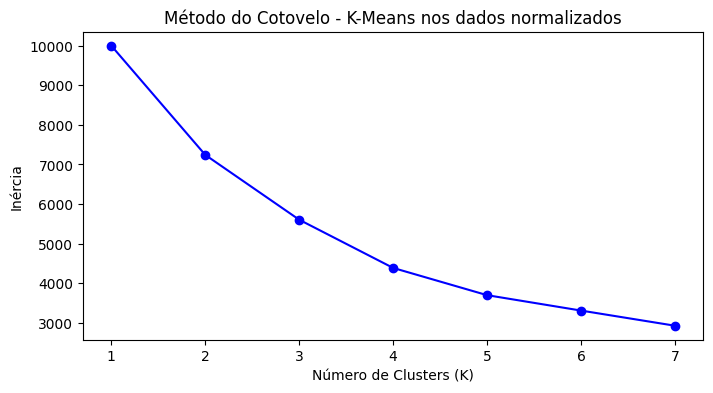

In [ ]:
lista_inercia = []
K_range = range(1, 8)

for k in K_range:
    modelo_kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo_kmeans.fit(X_scaled)

    lista_inercia.append(modelo_kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, lista_inercia, "bo-")
plt.xlabel("Número de Clusters (K)")
plt.ylabel("Inércia")
plt.title("Método do Cotovelo - K-Means nos dados normalizados")
plt.show()

In [ ]:
K_ideal = 3

kmeans_final = KMeans(
    n_clusters=K_ideal,
    random_state=42,
    n_init=10
)

clusters = kmeans_final.fit_predict(X_scaled)

df_clientes["cluster"] = clusters

silhouette = silhouette_score(X_scaled, clusters)

print(f"\nSilhouette Score do modelo final: {silhouette:.4f}")


Silhouette Score do modelo final: 0.4483


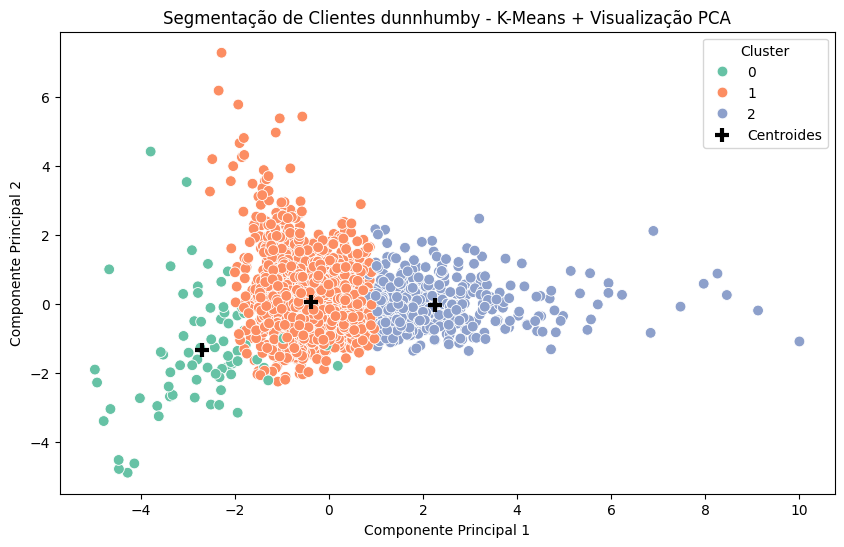

In [ ]:
df_visualizacao = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=df_clientes.index
)

df_visualizacao["cluster"] = clusters

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_visualizacao,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set2",
    s=60
)

centroides_pca = pca.transform(kmeans_final.cluster_centers_)

plt.scatter(
    centroides_pca[:, 0],
    centroides_pca[:, 1],
    marker="+",
    s=100,
    c="black",
    linewidths=3,
    label="Centroides"
)

plt.title("Segmentação de Clientes dunnhumby - K-Means + Visualização PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Cluster")
plt.show()

In [ ]:
perfil_clusters = (
    df_clientes
    .groupby("cluster")[features_clusterizacao]
    .mean()
)

perfil_clusters.rename(columns={'Recencia': 'Recência', 'Frequencia': 'Frequência', 'Gasto_Total': 'Gasto total', 'Percentual_Desconto': 'Desconto (%)'}, inplace=True)

print("\n--- Perfil médio de cada Cluster ---")
display(perfil_clusters.round(2))

qtd_clientes_cluster = (
    df_clientes["cluster"]
    .value_counts()
    .sort_index()
)

print("\n--- Quantidade de clientes por Cluster ---")
display(qtd_clientes_cluster)

percentual_clientes_cluster = (
    df_clientes["cluster"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("\n--- Percentual de clientes por Cluster ---")
display(percentual_clientes_cluster.round(2))


--- Perfil médio de cada Cluster ---


,Recência,Frequência,Gasto total,Desconto (%)
cluster,,,,
0,317.81,23.64,569.32,0.20
1,19.45,76.03,2119.49,0.19
2,3.69,286.47,8817.52,0.16



--- Quantidade de clientes por Cluster ---


,count
cluster,
0,74
1,1997
2,429



--- Percentual de clientes por Cluster ---


,proportion
cluster,
0,2.96
1,79.88
2,17.16


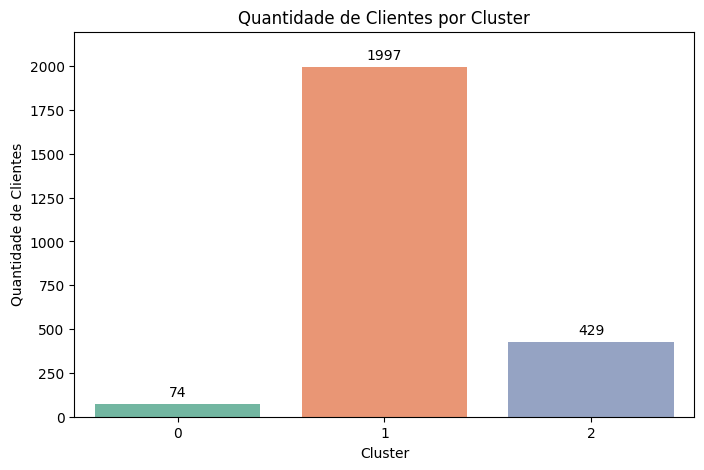

In [ ]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df_clientes,
    x="cluster",
    hue="cluster",
    palette="Set2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

ax.set_ylim(0, df_clientes["cluster"].value_counts().max() * 1.10)

plt.title("Quantidade de Clientes por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Quantidade de Clientes")
plt.show()

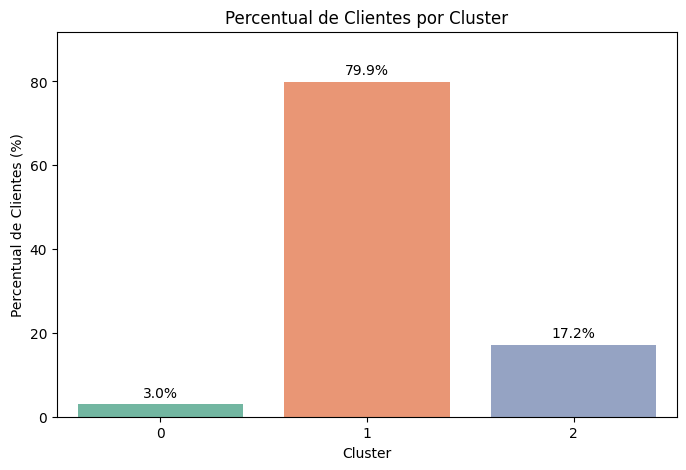

In [ ]:
percentual_plot = (
    df_clientes["cluster"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .reset_index()
)

percentual_plot.columns = ["cluster", "percentual"]

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=percentual_plot,
    x="cluster",
    y="percentual",
    hue="cluster",
    palette="Set2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Percentual de Clientes por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Percentual de Clientes (%)")
plt.ylim(0, percentual_plot["percentual"].max() * 1.15)
plt.show()

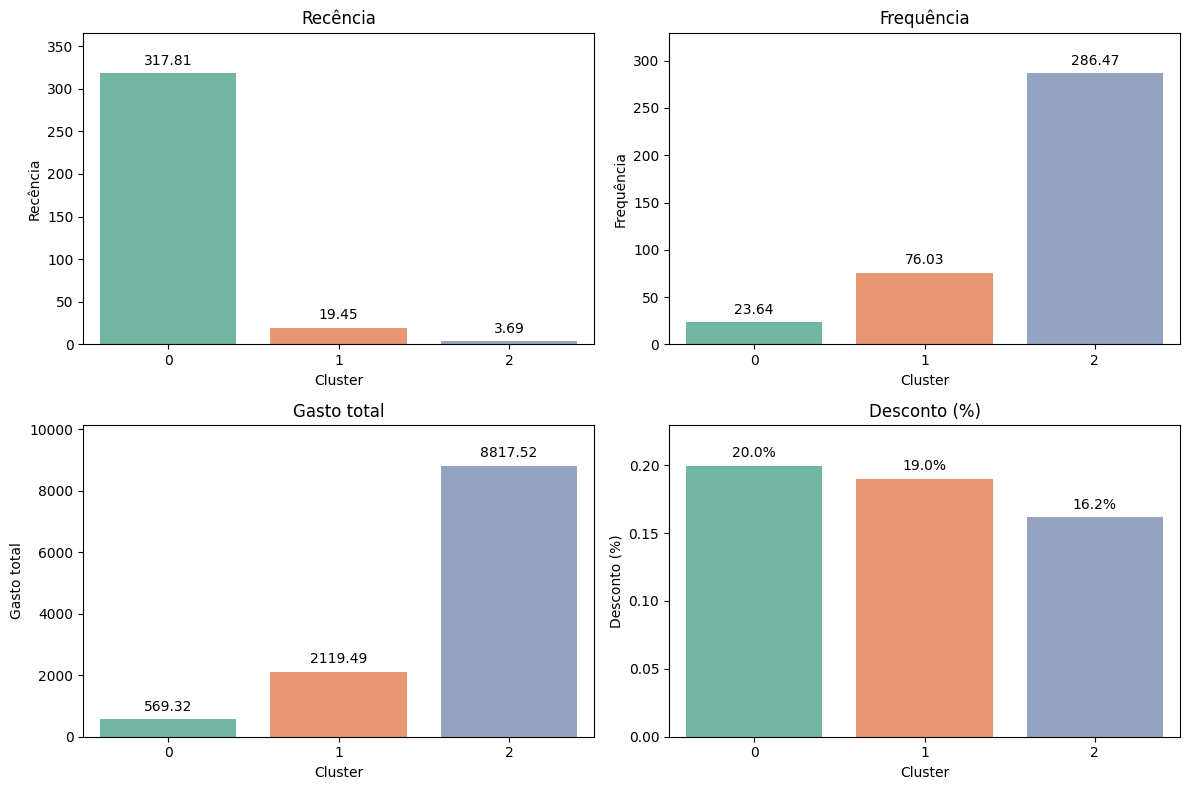

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

nomes_variaveis = {
    "Recencia": "Recência",
    "Frequencia": "Frequência",
    "Gasto_Total": "Gasto total",
    "Percentual_Desconto": "Desconto (%)"
}

for ax, var in zip(axs.flat, features_clusterizacao):

    medias = (
        df_clientes
        .groupby("cluster")[var]
        .mean()
        .reset_index()
    )

    sns.barplot(
        data=medias,
        x="cluster",
        y=var,
        hue="cluster",
        palette="Set2",
        legend=False,
        ax=ax
    )

    ax.set_ylim(0, medias[var].max() * 1.15)

    for p in ax.patches:
        altura = p.get_height()

        if var == "Percentual_Desconto":
            texto = f"{altura:.1%}"
        else:
            texto = f"{altura:.2f}"

        ax.annotate(
            texto,
            (p.get_x() + p.get_width() / 2, altura),
            ha="center",
            va="bottom",
            xytext=(0, 4),
            textcoords="offset points",
            fontsize=10
        )

    ax.set_title(nomes_variaveis[var], fontsize=12)
    ax.set_xlabel("Cluster")
    ax.set_ylabel(nomes_variaveis[var])

plt.tight_layout()
plt.show()